In [1]:
# SMS Spam Detection Project

# Data Loading

In [2]:
import pandas as pd

df = pd.read_csv("../artifact/spam.csv", encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


##Data Cleaning

In [3]:
# keep only required columns
df = df[['v1', 'v2']]

# rename columns
df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Exploratory Data Analysis (EDA)

### Dataset Information
This shows number of rows, columns, and data types.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


### Checking Missing Values
We check if any data is missing.

In [5]:
df.isnull().sum()

label      0
message    0
dtype: int64

### Label Distribution
This shows how many spam and ham messages are present.

In [6]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

### Visualization of Spam vs Ham
This graph shows the distribution of spam and ham messages.

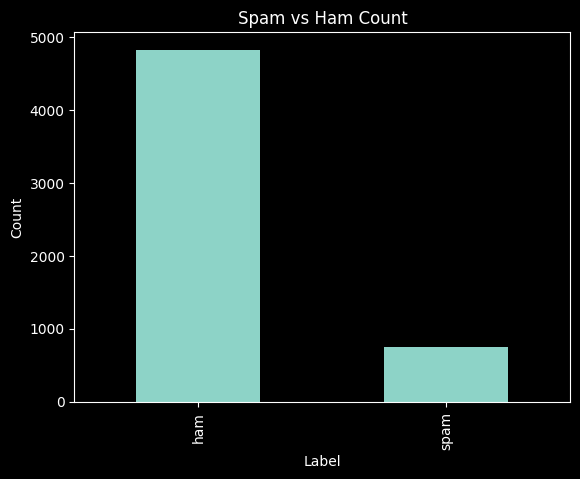

In [7]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Count")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# NLP Preprocessing (Text Cleaning)
We clean and prepare the text data for machine learning.

## Convert text to lowercase
All text is converted to lowercase for consistency.

In [8]:
df['message'] = df['message'].str.lower()
df.head()

,label,message
0,ham,"go until jurong point, crazy.. available only ..."
1,ham,ok lar... joking wif u oni...
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor... u c already then say...
4,ham,"nah i don't think he goes to usf, he lives aro..."


## Remove punctuation
Punctuation does not help in spam detection, so we remove it.

In [9]:
import string

df['message'] = df['message'].apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))
df.head()

,label,message
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...


## Remove numbers
Numbers are removed as they usually do not add meaning.

In [10]:
df['message'] = df['message'].str.replace(r'\d+', '', regex=True)
df.head()

,label,message
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in a wkly comp to win fa cup final...
3,ham,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...


## Tokenization
Split sentences into individual words (tokens).

In [12]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

df['message'] = df['message'].apply(nltk.word_tokenize)
df.head()

[nltk_data] Downloading package punkt to /home/ved/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/ved/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,label,message
0,ham,"[go, until, jurong, point, crazy, available, o..."
1,ham,"[ok, lar, joking, wif, u, oni]"
2,spam,"[free, entry, in, a, wkly, comp, to, win, fa, ..."
3,ham,"[u, dun, say, so, early, hor, u, c, already, t..."
4,ham,"[nah, i, dont, think, he, goes, to, usf, he, l..."


## Remove Stopwords
Common words like "is", "the", "and" are removed as they do not add meaning.

In [13]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df['message'] = df['message'].apply(lambda x: [word for word in x if word not in stop_words])
df.head()

[nltk_data] Downloading package stopwords to /home/ved/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,label,message
0,ham,"[go, jurong, point, crazy, available, bugis, n..."
1,ham,"[ok, lar, joking, wif, u, oni]"
2,spam,"[free, entry, wkly, comp, win, fa, cup, final,..."
3,ham,"[u, dun, say, early, hor, u, c, already, say]"
4,ham,"[nah, dont, think, goes, usf, lives, around, t..."


## Stemming
Words are reduced to their root form.

In [14]:
from nltk.stem import PorterStemmer

ps = PorterStemmer()

df['message'] = df['message'].apply(lambda x: [ps.stem(word) for word in x])
df.head()

,label,message
0,ham,"[go, jurong, point, crazi, avail, bugi, n, gre..."
1,ham,"[ok, lar, joke, wif, u, oni]"
2,spam,"[free, entri, wkli, comp, win, fa, cup, final,..."
3,ham,"[u, dun, say, earli, hor, u, c, alreadi, say]"
4,ham,"[nah, dont, think, goe, usf, live, around, tho..."


## Convert tokens back to sentence
We join the cleaned words back into a single string for vectorization.

In [15]:
df['message'] = df['message'].apply(lambda x: " ".join(x))
df.head()

,label,message
0,ham,go jurong point crazi avail bugi n great world...
1,ham,ok lar joke wif u oni
2,spam,free entri wkli comp win fa cup final tkt st m...
3,ham,u dun say earli hor u c alreadi say
4,ham,nah dont think goe usf live around though


# TF-IDF Vectorization
Convert text data into numerical form using TF-IDF.

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['message']).toarray()
y = df['label']

# Train Test Split
Split data into training and testing sets.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

# Model Training - Naive Bayes
Train a machine learning model to classify spam and ham.

In [18]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


# Prediction
Use the trained model to predict on test data.

In [19]:
y_pred = model.predict(X_test)

# Model Evaluation
Check how accurate the model is.

In [20]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.967713004484305

In [22]:
import pickle

pickle.dump(tfidf, open('../artifact/vectorizer.pkl','wb'))
pickle.dump(model, open('../artifact/model.pkl','wb'))